<a href="https://colab.research.google.com/github/Lidahorbach/spotify-popularity-analysis/blob/main/bts_popularity_mvc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Loading and preparing data...
Data ready: N=296 tracks, M=3 mixture components.
Minimax weights matrix A calculated successfully.
Training Neural Network Experts...
Training completed.


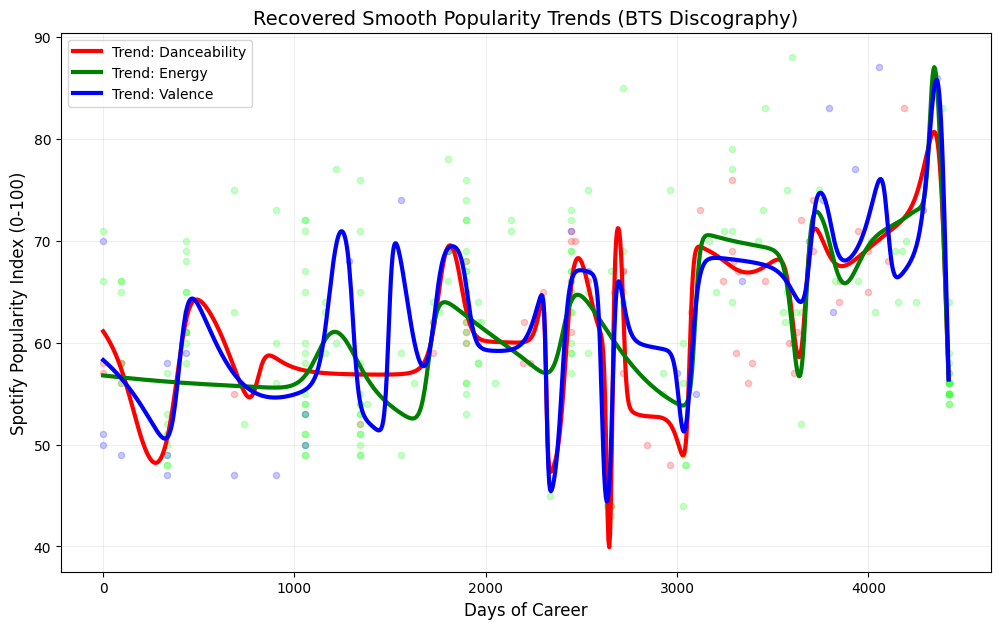

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

# ==========================================
# 1. DATA PREPARATION
# ==========================================
print("Loading and preparing data...")
df = pd.read_csv('This_Is_BTS.csv')

# Time variable (X): Days since first release
df['Release Date'] = pd.to_datetime(df['Release Date'])
min_date = df['Release Date'].min()
df['X_days'] = (df['Release Date'] - min_date).dt.days
df = df.sort_values('X_days')

X = df['X_days'].values.reshape(-1, 1)

# Target variable (Y): Popularity
Y = df['Popularity'].values.reshape(-1, 1)

# Concentration Matrix (P): Audio features acting as expert weights
features = ['Danceability', 'Energy', 'Valence']
P_raw = df[features].values
P = P_raw / P_raw.sum(axis=1, keepdims=True) # Row normalization

print(f"Data ready: N={len(df)} tracks, M=3 mixture components.")

# ==========================================
# 2. MINIMAX WEIGHTS CALCULATION
# ==========================================
# Analytically calculating the projection matrix A using the inverse Gram matrix
A = P.dot(np.linalg.inv(P.T.dot(P)))
print("Minimax weights matrix A calculated successfully.")

# ==========================================
# 3. NEURAL NETWORK EXPERTS SETUP
# ==========================================
# Data scaling for stable gradient descent
Y_mean, Y_std = Y.mean(), Y.std()
Y_scaled = (Y - Y_mean) / Y_std

X_tensor = torch.FloatTensor(X)
Y_tensor = torch.FloatTensor(Y_scaled)
A_tensor = torch.FloatTensor(A)

# Standardize X for the neural network
X_mean_t, X_std_t = X_tensor.mean(), X_tensor.std()
X_norm = (X_tensor - X_mean_t) / X_std_t

class SmoothExpert(nn.Module):
    """
    Multilayer Perceptron (MLP) with Tanh activation
    to ensure smooth and differentiable trend lines.
    """
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)

# Initialize 3 distinct models (one for each musical style)
experts = [SmoothExpert() for _ in range(3)]
optimizers = [optim.AdamW(exp.parameters(), lr=0.005, weight_decay=1e-4) for exp in experts]

# ==========================================
# 4. TRAINING LOOP
# ==========================================
print("Training Neural Network Experts...")
epochs = 2000

for epoch in range(epochs):
    for k in range(3):
        optimizers[k].zero_grad()
        y_pred = experts[k](X_norm)

        # Apply minimax weights for the k-th component
        weights = A_tensor[:, k].reshape(-1, 1)

        # Weighted MAE/MSE loss focusing on the target component while penalizing noise
        loss = torch.mean(torch.abs(weights) * (Y_tensor - y_pred)**2)

        loss.backward()
        optimizers[k].step()

print("Training completed.")

# ==========================================
# 5. VISUALIZATION & TREND RECOVERY
# ==========================================
plt.figure(figsize=(12, 7))

# 5.1 Plotting the actual scatter points colored by dominant feature
domination = np.argmax(P, axis=1)
colors = ['#FF4B4B', '#4BFF4B', '#4B4BFF'] # Red, Green, Blue
labels = ['Danceability', 'Energy', 'Valence']

for k in range(3):
    mask = (domination == k)
    plt.scatter(X[mask], Y[mask], c=colors[k], alpha=0.3, s=20)

# 5.2 Generating smooth trend lines across the entire timeline
X_grid = np.linspace(X.min(), X.max(), 1000).reshape(-1, 1)
X_grid_t = torch.FloatTensor(X_grid)
X_grid_norm = (X_grid_t - X_mean_t) / X_std_t

with torch.no_grad():
    trends = []
    for exp in experts:
        pred_scaled = exp(X_grid_norm).numpy()
        pred_real = pred_scaled * Y_std + Y_mean # Reversing the scaling to 0-100 popularity
        trends.append(pred_real)

# 5.3 Overlaying the trends
plt.plot(X_grid, trends[0], color='red', linewidth=3, label='Trend: Danceability')
plt.plot(X_grid, trends[1], color='green', linewidth=3, label='Trend: Energy')
plt.plot(X_grid, trends[2], color='blue', linewidth=3, label='Trend: Valence')

plt.title('Recovered Smooth Popularity Trends (BTS Discography)', fontsize=14)
plt.xlabel('Days of Career', fontsize=12)
plt.ylabel('Spotify Popularity Index (0-100)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()